<a href="https://colab.research.google.com/github/vinitdarji16/MLS-Exercise/blob/main/trafficlight_exercise9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile
import os

dataset_path = "/content/drive/MyDrive/dataset for MLS"

for file in [
    "train.zip",
    "validation.zip",
    "test.zip"
]:
    zip_path = os.path.join(dataset_path, file)

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall("/content/dataset")

print("Dataset extracted successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset extracted successfully!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from PIL import Image
import os

train_labels = pd.read_csv(
    "/content/dataset/train/labels.csv"
)

val_labels = pd.read_csv(
    "/content/dataset/validation/labels.csv"
)

test_labels = pd.read_csv(
    "/content/dataset/test/labels.csv"
)

print("Training images:", len(train_labels))
print("Validation images:", len(val_labels))
print("Test images:", len(test_labels))

Training images: 7200
Validation images: 3600
Test images: 3600


In [4]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms created successfully!")

Transforms created successfully!


In [5]:
class CarlaDataset(Dataset):

    def __init__(
        self,
        image_folder,
        labels_df,
        target_column,
        transform=None
    ):
        self.image_folder = image_folder
        self.labels_df = labels_df
        self.target_column = target_column
        self.transform = transform

    def __len__(self):
        return len(self.labels_df)

    def __getitem__(self, idx):

        frame = self.labels_df.iloc[idx]["frame"]

        image_name = f"{frame:06d}.jpg"

        image_path = os.path.join(
            self.image_folder,
            image_name
        )

        image = Image.open(
            image_path
        ).convert("RGB")

        label = int(
            self.labels_df.iloc[idx][
                self.target_column
            ]
        )

        if self.transform:
            image = self.transform(image)

        return image, label

print("Dataset class created successfully!")

Dataset class created successfully!


In [6]:
train_image_folder = (
    "/content/dataset/train/rgb-front"
)

val_image_folder = (
    "/content/dataset/validation/rgb-front"
)

traffic_train_dataset = CarlaDataset(
    train_image_folder,
    train_labels,
    "has_traffic_light",
    transform
)

traffic_val_dataset = CarlaDataset(
    val_image_folder,
    val_labels,
    "has_traffic_light",
    transform
)

train_loader = DataLoader(
    traffic_train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    traffic_val_dataset,
    batch_size=32,
    shuffle=False
)

print("Traffic Light datasets created!")
print("Training samples:", len(traffic_train_dataset))
print("Validation samples:", len(traffic_val_dataset))

Traffic Light datasets created!
Training samples: 7200
Validation samples: 3600


In [7]:
model = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

num_features = model.fc.in_features

model.fc = nn.Linear(
    num_features,
    1
)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

model = model.to(device)

print("Model created!")
print("Device:", device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 177MB/s]


Model created!
Device: cuda


In [8]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss and optimizer created successfully!")

Loss and optimizer created successfully!


In [9]:
num_epochs = 10

train_losses = []
val_losses = []

for epoch in range(num_epochs):

    # TRAINING
    model.train()

    running_train_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)

        labels = (
            labels.float()
            .unsqueeze(1)
            .to(device)
        )

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = (
        running_train_loss /
        len(train_loader)
    )

    train_losses.append(
        avg_train_loss
    )

    # VALIDATION
    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            labels = (
                labels.float()
                .unsqueeze(1)
                .to(device)
            )

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_val_loss += loss.item()

    avg_val_loss = (
        running_val_loss /
        len(val_loader)
    )

    val_losses.append(
        avg_val_loss
    )

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f}"
    )

print("Training completed!")

Epoch [1/10] | Train Loss: 0.1793 | Val Loss: 0.6595
Epoch [2/10] | Train Loss: 0.0845 | Val Loss: 0.1076
Epoch [3/10] | Train Loss: 0.0731 | Val Loss: 0.0725
Epoch [4/10] | Train Loss: 0.0524 | Val Loss: 0.1071
Epoch [5/10] | Train Loss: 0.0469 | Val Loss: 0.0739
Epoch [6/10] | Train Loss: 0.0440 | Val Loss: 0.0748
Epoch [7/10] | Train Loss: 0.0327 | Val Loss: 0.0736
Epoch [8/10] | Train Loss: 0.0328 | Val Loss: 0.0785
Epoch [9/10] | Train Loss: 0.0248 | Val Loss: 0.0929
Epoch [10/10] | Train Loss: 0.0222 | Val Loss: 0.1101
Training completed!


In [10]:
model_path = (
    "/content/drive/MyDrive/"
    "traffic_light_model.pth"
)

torch.save(
    model.state_dict(),
    model_path
)

print(
    "Traffic Light model saved successfully!"
)
print(model_path)

Traffic Light model saved successfully!
/content/drive/MyDrive/traffic_light_model.pth


In [11]:
test_image_folder = (
    "/content/dataset/test/rgb-front"
)

traffic_test_dataset = CarlaDataset(
    test_image_folder,
    test_labels,
    "has_traffic_light",
    transform
)

test_loader = DataLoader(
    traffic_test_dataset,
    batch_size=32,
    shuffle=False
)

model.eval()

print(
    "Traffic Light test loader ready!"
)

Traffic Light test loader ready!


In [12]:
model.eval()

all_probs = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        probs = torch.sigmoid(outputs)

        all_probs.extend(
            probs.cpu().numpy().flatten()
        )

        all_labels.extend(
            labels.numpy()
        )

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

print(
    "Collected",
    len(all_probs),
    "predictions"
)

Collected 3600 predictions


In [13]:
def compute_ece(
    probs,
    labels,
    n_bins=10
):

    bins = np.linspace(
        0,
        1,
        n_bins + 1
    )

    ece = 0.0

    for i in range(n_bins):

        mask = (
            (probs >= bins[i]) &
            (probs < bins[i + 1])
        )

        if np.sum(mask) > 0:

            bin_acc = np.mean(
                labels[mask] ==
                (probs[mask] > 0.5)
            )

            bin_conf = np.mean(
                probs[mask]
            )

            ece += (
                np.abs(
                    bin_acc - bin_conf
                )
                * np.sum(mask)
                / len(probs)
            )

    return ece


ece = compute_ece(
    all_probs,
    all_labels
)

print(
    f"ECE = {ece:.4f}"
)

ECE = 0.2616


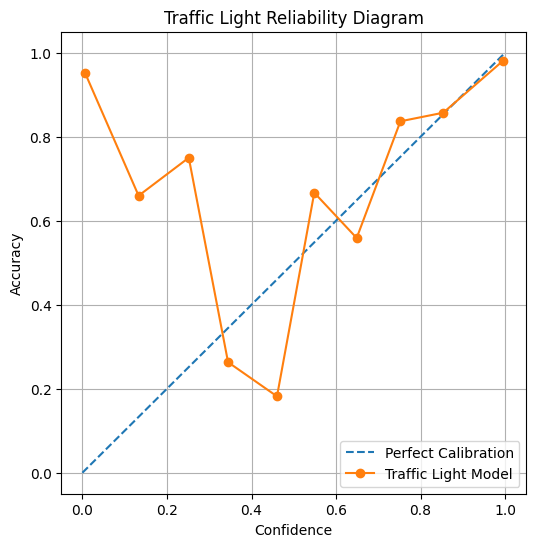

In [14]:
bins = np.linspace(
    0,
    1,
    11
)

bin_accs = []
bin_confs = []

for i in range(10):

    mask = (
        (all_probs >= bins[i]) &
        (all_probs < bins[i + 1])
    )

    if np.sum(mask) > 0:

        acc = np.mean(
            all_labels[mask] ==
            (all_probs[mask] > 0.5)
        )

        conf = np.mean(
            all_probs[mask]
        )

        bin_accs.append(acc)
        bin_confs.append(conf)

plt.figure(figsize=(6,6))

plt.plot(
    [0,1],
    [0,1],
    "--",
    label="Perfect Calibration"
)

plt.plot(
    bin_confs,
    bin_accs,
    marker="o",
    label="Traffic Light Model"
)

plt.xlabel("Confidence")
plt.ylabel("Accuracy")
plt.title(
    "Traffic Light Reliability Diagram"
)

plt.legend()
plt.grid(True)

plt.show()

In [15]:
temperatures = [
    0.5,
    1.0,
    2.0
]

ece_results = {}

for T in temperatures:

    scaled_probs = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)

            outputs = model(images)

            probs = torch.sigmoid(
                outputs / T
            )

            scaled_probs.extend(
                probs.cpu()
                .numpy()
                .flatten()
            )

    scaled_probs = np.array(
        scaled_probs
    )

    ece_T = compute_ece(
        scaled_probs,
        all_labels
    )

    ece_results[T] = ece_T

    print(
        f"Temperature = {T}"
    )

    print(
        f"ECE = {ece_T:.4f}"
    )

    print("-" * 30)


best_T = min(
    ece_results,
    key=ece_results.get
)

print(
    "Best Temperature =",
    best_T
)

print(
    "Best ECE =",
    ece_results[best_T]
)

Temperature = 0.5
ECE = 0.2731
------------------------------
Temperature = 1.0
ECE = 0.2616
------------------------------
Temperature = 2.0
ECE = 0.2534
------------------------------
Best Temperature = 2.0
Best ECE = 0.25337576855491434


In [16]:
scaled_probs = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        probs = torch.sigmoid(
            outputs / best_T
        )

        scaled_probs.extend(
            probs.cpu()
            .numpy()
            .flatten()
        )

scaled_probs = np.array(
    scaled_probs
)

ece_scaled = compute_ece(
    scaled_probs,
    all_labels
)

print(
    "ECE Before =",
    ece
)

print(
    "ECE After  =",
    ece_scaled
)

print(
    "Best Temperature =",
    best_T
)

print(
    "ECE Improvement =",
    ece - ece_scaled
)

ECE Before = 0.26156989436286193
ECE After  = 0.25337576855491434
Best Temperature = 2.0
ECE Improvement = 0.008194125807947594


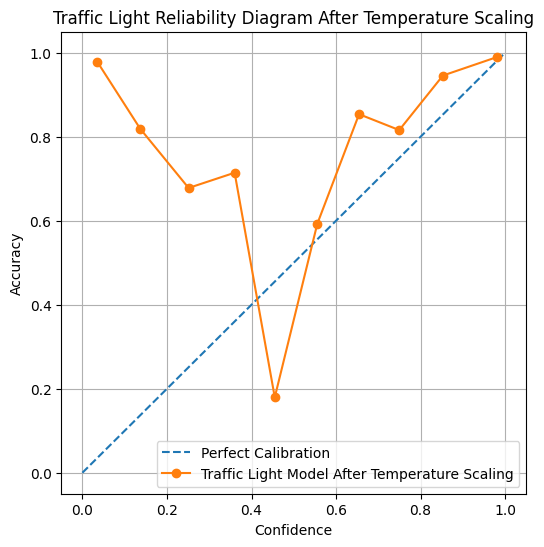

In [17]:
bins = np.linspace(
    0,
    1,
    11
)

bin_accs = []
bin_confs = []

for i in range(10):

    mask = (
        (scaled_probs >= bins[i]) &
        (scaled_probs < bins[i + 1])
    )

    if np.sum(mask) > 0:

        acc = np.mean(
            all_labels[mask] ==
            (scaled_probs[mask] > 0.5)
        )

        conf = np.mean(
            scaled_probs[mask]
        )

        bin_accs.append(acc)
        bin_confs.append(conf)

plt.figure(figsize=(6,6))

plt.plot(
    [0,1],
    [0,1],
    "--",
    label="Perfect Calibration"
)

plt.plot(
    bin_confs,
    bin_accs,
    marker="o",
    label=(
        "Traffic Light Model "
        "After Temperature Scaling"
    )
)

plt.xlabel("Confidence")
plt.ylabel("Accuracy")

plt.title(
    "Traffic Light Reliability Diagram "
    "After Temperature Scaling"
)

plt.legend()
plt.grid(True)

plt.show()

In [18]:
criterion = nn.BCEWithLogitsLoss()

val_logits = []
val_labels_nll = []

model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        outputs = model(images)

        val_logits.extend(
            outputs.cpu().numpy().flatten()
        )

        val_labels_nll.extend(
            labels.numpy()
        )

val_logits = np.array(val_logits)
val_labels_nll = np.array(val_labels_nll)

print("Validation predictions:", len(val_logits))

Validation predictions: 3600


In [19]:
temperatures = np.round(
    np.arange(0.5, 3.01, 0.1),
    1
)

nll_results = {}

for T in temperatures:

    scaled_logits = val_logits / T

    logits_tensor = torch.tensor(
        scaled_logits,
        dtype=torch.float32
    ).unsqueeze(1)

    labels_tensor = torch.tensor(
        val_labels_nll,
        dtype=torch.float32
    ).unsqueeze(1)

    nll = criterion(
        logits_tensor,
        labels_tensor
    ).item()

    nll_results[T] = nll

    print(
        f"T = {T:.1f} | "
        f"Validation NLL = {nll:.6f}"
    )

best_T = min(
    nll_results,
    key=nll_results.get
)

print()
print("Best Temperature =", best_T)
print("Best Validation NLL =", nll_results[best_T])

T = 0.5 | Validation NLL = 0.187435
T = 0.6 | Validation NLL = 0.159626
T = 0.7 | Validation NLL = 0.140477
T = 0.8 | Validation NLL = 0.126801
T = 0.9 | Validation NLL = 0.116837
T = 1.0 | Validation NLL = 0.109536
T = 1.1 | Validation NLL = 0.104234
T = 1.2 | Validation NLL = 0.100492
T = 1.3 | Validation NLL = 0.098004
T = 1.4 | Validation NLL = 0.096549
T = 1.5 | Validation NLL = 0.095960
T = 1.6 | Validation NLL = 0.096111
T = 1.7 | Validation NLL = 0.096896
T = 1.8 | Validation NLL = 0.098233
T = 1.9 | Validation NLL = 0.100050
T = 2.0 | Validation NLL = 0.102286
T = 2.1 | Validation NLL = 0.104890
T = 2.2 | Validation NLL = 0.107815
T = 2.3 | Validation NLL = 0.111021
T = 2.4 | Validation NLL = 0.114472
T = 2.5 | Validation NLL = 0.118136
T = 2.6 | Validation NLL = 0.121983
T = 2.7 | Validation NLL = 0.125990
T = 2.8 | Validation NLL = 0.130131
T = 2.9 | Validation NLL = 0.134387
T = 3.0 | Validation NLL = 0.138739

Best Temperature = 1.5
Best Validation NLL = 0.0959604829549789

In [20]:
scaled_probs = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        probs = torch.sigmoid(
            outputs / best_T
        )

        scaled_probs.extend(
            probs.cpu()
            .numpy()
            .flatten()
        )

scaled_probs = np.array(
    scaled_probs
)

ece_after = compute_ece(
    scaled_probs,
    all_labels
)

ece_before = compute_ece(
    all_probs,
    all_labels
)

print(
    "ECE Before =",
    ece_before
)

print(
    "ECE After  =",
    ece_after
)

print(
    "Best Temperature =",
    best_T
)

print(
    "ECE Improvement =",
    ece_before - ece_after
)

ECE Before = 0.26156989436286193
ECE After  = 0.24948571105901562
Best Temperature = 1.5
ECE Improvement = 0.012084183303846308
